In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import itertools

from snn import Network, NodeGroup, EdgeGroup, NodePort, NodeList
from snn.model import IN, LIF, PSP

In [2]:
class Input(Network):
    def __init__(self, spike_times, ctrl_times):
        super().__init__()
        # inputs to snn is generally tricky
        # here we use lists of spike times
        self.spike_times = spike_times # n x t
        self.ctrl_times = ctrl_times   # 1 x t

    def build(self):
        self.spikegen = NodeGroup(IN(), len(self.spike_times), times=self.spike_times)
        self.ctrl_out = NodeGroup(IN(), 1, times=self.ctrl_times)

        return

In [3]:
class Adder(Network):
    def __init__(self):
        super().__init__()
        self.input = NodePort() # number of inputs generates a dependency
        self.ctrl_in = NodePort(1)

    def build(self):
        num_input = len(self.input)
        num_carry = 2 * num_input - 1
        self.carry = NodeGroup(LIF(), num_carry, threshold=[0.9+i for i in range(num_carry)])
        self.output = NodeGroup(LIF(threshold=0.9), 1) # default params can go in node model

        # Input to Carry
        # edges = list()
        # for i in range(num_input):
        #     for c in range(num_carry):
        #         edges.append((i,c))
        self.ic = EdgeGroup(self.input, self.carry, PSP(),
                            list(itertools.product(range(num_input), range(num_carry))))

        # Carry to Carry
        edges = list()
        i = 1
        for c1 in range(1,num_carry,2):
            for c2 in range(c1-i,num_carry):
                edges.append((c1,c2))
            i += 1
        self.cc = EdgeGroup(self.carry, self.carry, PSP(), edges)

        # Carry to Output
        # pos_edges = list()
        # neg_edges = list()
        # for c in range(num_carry):
        #     if c%2 == 0:
        #         pos_edges.append((c,0))
        #     else:
        #         neg_edges.append((c,0))
        # self.co_pos = EdgeGroup(self.carry, self.output, PSP(), pos_edges)
        # self.co_neg = EdgeGroup(self.carry, self.output, PSP(weight=-1.0), neg_edges)
        self.co = EdgeGroup(self.carry, self.output, PSP(),
                            edges=[(i,0) for i in range(num_carry)],
                            weight=[1.0 - (i%2)*2.0 for i in range(num_carry)])

        return

In [4]:
class Subtractor(Network):
    def __init__(self, len_inputs=4):
        super().__init__()
        # how long the numbers are
        self.len_inputs = len_inputs
        # input ports
        self.input = NodePort(2)
        # input helper node lists (these can go in build, too)
        self.a = NodeList([self.input[0]])
        self.b = NodeList([self.input[1]])
        # Ports can work here too (but need a different connect)
        # self.a = NodePort(1)
        # self.b = NodePort(1)
        # for timing against the start of the input
        self.ctrl_in = NodePort(1)

    def build(self):
        # Inversion
        # single neuron instantiation (default node size is 1)
        self.not_b = NodeGroup(LIF(threshold=0.9))
        # single synapse connection (default edge is (0, 0))
        self.b__nb = EdgeGroup(self.b, self.not_b, PSP(), weight=-1.0, delay=2.0)
        
        # Control relay (based on length of inputs)
        self.ctrl_relay = NodeGroup(LIF(), self.len_inputs, threshold=0.9)
        self.ci__r = EdgeGroup(self.ctrl_in, self.ctrl_relay, PSP(),
                               edges=[(0, i) for i in range(self.len_inputs)])
        self.cr__nb = EdgeGroup(self.ctrl_relay, self.not_b, PSP(),
                                edges=[(i, 0) for i in range(self.len_inputs)],
                                delay=[1.0 + i for i in range(self.len_inputs)])
        
        # Add 1 relay (to get the timing right)
        self.one_relay = NodeGroup(LIF(threshold=0.9))
        self.ci__or = EdgeGroup(self.ctrl_in, self.one_relay, PSP(), delay=2.0)
        
        # First Adder to get -B
        self.adder_b_input = NodeList([self.not_b[0], self.one_relay[0]])
        self.adder_b = Adder()
        self.connect(self.adder_b_input, self.adder_b.input)

        # A input relay (to get the timing right)
        self.a_relay = NodeGroup(LIF(), 1, threshold=0.9)
        self.a__ar = EdgeGroup(self.a, self.a_relay, PSP(), delay=5.0)

        # Second Adder for A - B
        self.adder_ab_input = NodeList([self.a_relay[0], self.adder_b.output[0]])
        self.adder_ab = Adder()
        self.connect(self.adder_ab_input, self.adder_ab.input)

        # Output
        self.output = NodeGroup(LIF(threshold=0.9), 1)
        self.ab__o = EdgeGroup(self.adder_b.output, self.output, PSP())

        # Supress final carry out (not sure if this is needed)
        self.ci__o = EdgeGroup(self.ctrl_in, self.output, PSP(),
                               weight=-1, delay=11.0)

        # Output start timing (for downstream)
        self.ctrl_out = NodeGroup(LIF(threshold=0.9))
        self.ci__co = EdgeGroup(self.ctrl_in, self.ctrl_out, PSP(), delay=9.0)

        return

In [5]:
input_vec = [[0, 3, 5], # 1,0,1,0,0,1
             [1, 2, 4]] # 0,1,0,1,1,0
ctrl_vec  = [[0]]

net = Network()
net.i = Input(spike_times=input_vec, ctrl_times=ctrl_vec)
net.s = Subtractor(len_inputs=6)
net.connect(net.i.spikegen, net.s.input)
# if a and b are ports, could also do this
# net.s_a = NodeList([net.i.spikegen[0]])
# net.s_b = NodeList([net.i.spikegen[1]])
# net.connect(net.s_a, net.s.a)
# net.connect(net.s_b, net.s.b)
net.connect(net.i.ctrl_out, net.s.ctrl_in)

info: adding network
info: adding network


In [6]:
net.build()

info: building i
info: building s
info: adding network
info: adding network
info: linking port as target
info: linking port as target
info: dependency resolved for input
info: dependency resolved for input
info: building adder_b
info: building adder_ab
info: linking port as target
info: linking port as target
info: flattening network topology


In [7]:
net._topology

namespace(_network=<snn.network.Network at 0x11bd97650>,
          edgegroups=[],
          i=namespace(_network=<__main__.Input at 0x11bd97c50>,
                      edgegroups=[],
                      spikegen=[<snn.core.Node at 0x11b5afec0>,
                      ctrl_out=[<snn.core.Node at 0x11bd95d40>]),
          s=namespace(_network=<__main__.Subtractor at 0x11b188ad0>,
                      edgegroups=[],
                      input=[<snn.core.Link at 0x11bda5150>,
                      a=[<snn.core.Node at 0x11b5afec0>],
                      b=[<snn.core.Node at 0x11bd88b80>],
                      ctrl_in=[<snn.core.Link at 0x11bda5210>],
                      not_b=[<snn.core.Node at 0x11ba055c0>],
                      b__nb=[<snn.core.Edge at 0x11bd7f510>],
                      ctrl_relay=[<snn.core.Node at 0x11bd8a880>,
                      ci__r=[<snn.core.Edge at 0x11bd7f5b0>,
                      cr__nb=[<snn.core.Edge at 0x11bd7f7e0>,
                      one_r

In [8]:
print(net)

(node) i.spikegen
(node) i.ctrl_out
(port) s.input <- (node) i.spikegen
(list) s.a
(list) s.b
(port) s.ctrl_in <- (node) i.ctrl_out
(node) s.not_b
(edge) s.b__nb: (list) s.b -> (node) s.not_b
(node) s.ctrl_relay
(edge) s.ci__r: (port) s.ctrl_in <- (node) i.ctrl_out -> (node) s.ctrl_relay
(edge) s.cr__nb: (node) s.ctrl_relay -> (node) s.not_b
(node) s.one_relay
(edge) s.ci__or: (port) s.ctrl_in <- (node) i.ctrl_out -> (node) s.one_relay
(list) s.adder_b_input
(node) s.a_relay
(edge) s.a__ar: (list) s.a -> (node) s.a_relay
(list) s.adder_ab_input
(node) s.output
(edge) s.ab__o: (node) s.adder_b.output -> (node) s.output
(edge) s.ci__o: (port) s.ctrl_in <- (node) i.ctrl_out -> (node) s.output
(node) s.ctrl_out
(edge) s.ci__co: (port) s.ctrl_in <- (node) i.ctrl_out -> (node) s.ctrl_out
(port) s.adder_b.input <- (list) s.adder_b_input
(port) s.adder_b.ctrl_in <- (no link)
(node) s.adder_b.carry
(node) s.adder_b.output
(edge) s.adder_b.ic: (port) s.adder_b.input <- (list) s.adder_b_input -> 

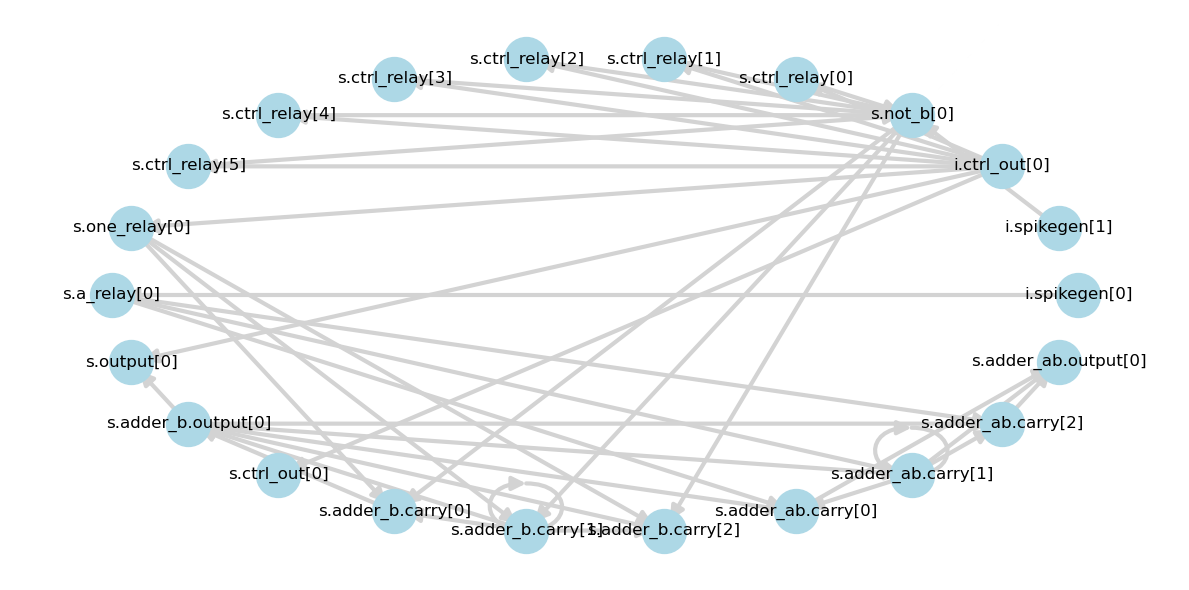

In [9]:
# could have some better visualization
#nx.draw(net._graph, nx.circular_layout(net._graph), with_labels=True)
plt.figure(figsize=(12, 6))
pos = nx.circular_layout(net._graph)
nx.draw_networkx_nodes(net._graph, pos, node_size=1000, node_color='lightblue')
nx.draw_networkx_edges(net._graph, pos, edge_color='lightgray', width=3, arrowsize=20)
nx.draw_networkx_labels(net._graph, pos, font_size=12, font_color='black')
plt.axis('off')
plt.tight_layout()

In [10]:
print(net._graph.number_of_nodes())
print(net._graph.number_of_edges())

22
42


In [11]:
# Flattened graph (target major, e.g. node followed by incoming edges)
for node in net._graph.nodes:
    info = []
    info.append(f"{node} {net._graph.nodes[node]}")
    for u, v, data in net._graph.in_edges(node, data=True):
        info.append(f"\n  | {u} {data}")
    print (' '.join(info))

i.spikegen[0] {'model': 'IN', 'times': [0, 3, 5]}
i.spikegen[1] {'model': 'IN', 'times': [1, 2, 4]}
i.ctrl_out[0] {'model': 'IN', 'times': [0]}
s.not_b[0] {'model': 'LIF', 'voltage': 0.0, 'threshold': 0.9, 'reset': 0.0, 'bias': 0.0, 'leak': 1.0} 
  | i.spikegen[1] {'model': 'PSP', 'delay': 2.0, 'weight': -1.0} 
  | s.ctrl_relay[0] {'model': 'PSP', 'delay': 1.0, 'weight': 1.0} 
  | s.ctrl_relay[1] {'model': 'PSP', 'delay': 2.0, 'weight': 1.0} 
  | s.ctrl_relay[2] {'model': 'PSP', 'delay': 3.0, 'weight': 1.0} 
  | s.ctrl_relay[3] {'model': 'PSP', 'delay': 4.0, 'weight': 1.0} 
  | s.ctrl_relay[4] {'model': 'PSP', 'delay': 5.0, 'weight': 1.0} 
  | s.ctrl_relay[5] {'model': 'PSP', 'delay': 6.0, 'weight': 1.0}
s.ctrl_relay[0] {'model': 'LIF', 'voltage': 0.0, 'threshold': 0.9, 'reset': 0.0, 'bias': 0.0, 'leak': 1.0} 
  | i.ctrl_out[0] {'model': 'PSP', 'delay': 1.0, 'weight': 1.0}
s.ctrl_relay[1] {'model': 'LIF', 'voltage': 0.0, 'threshold': 0.9, 'reset': 0.0, 'bias': 0.0, 'leak': 1.0} 
  | i.